<a href="https://colab.research.google.com/github/Cshoga/Intro-to-ML_Summative/blob/main/Student_academic_prediction_notebook_celine_shoga.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import libraries

I start by importing the libraries for data analysis, machine learning, deep learning, and plotting.

In [ ]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print("Libraries imported.")
print("TensorFlow version:", tf.__version__)

Libraries imported.
TensorFlow version: 2.20.0


## 2. Load the dataset

I loaded the dataset from the Github repo


In [ ]:
GITHUB_RAW_URL = "https://raw.githubusercontent.com/Cshoga/Intro-to-ML_Summative/main/data.csv"

DATA_PATH = GITHUB_RAW_URL

df = pd.read_csv(DATA_PATH, sep=";")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully.
Shape: (4424, 37)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 3. Quick dataset check

Here I check the columns, missing values, duplicate rows, and target distribution.
This helps me understand the dataset before modelling.

In [ ]:
print("Number of rows and columns:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
print(df["Target"].value_counts())

Number of rows and columns: (4424, 37)

Columns:
['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance\t', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate

## 4. Clean column names

Some column names have spaces or special characters. I clean them so they are easier to use in Python.

In [ ]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("/", "_")
    .str.replace("(", "", regex=False)
    .str.replace(")", "", regex=False)
)

print("Cleaned columns:")
print(df.columns.tolist()[:10])

Cleaned columns:
['Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', "Mother's_qualification", "Father's_qualification"]


## 5. Simple feature engineering

I created a few extra features from the semester information.  
These features are simple, but they may help the models understand student academic progress better.

In [ ]:
df_fe = df.copy()

df_fe["Total_approved_units"] = (
    df_fe["Curricular_units_1st_sem_approved"] +
    df_fe["Curricular_units_2nd_sem_approved"]
)

df_fe["Average_semester_grade"] = (
    df_fe["Curricular_units_1st_sem_grade"] +
    df_fe["Curricular_units_2nd_sem_grade"]
) / 2

df_fe["Total_evaluations"] = (
    df_fe["Curricular_units_1st_sem_evaluations"] +
    df_fe["Curricular_units_2nd_sem_evaluations"]
)

df_fe["Total_enrolled_units"] = (
    df_fe["Curricular_units_1st_sem_enrolled"] +
    df_fe["Curricular_units_2nd_sem_enrolled"]
)

print("Shape after feature engineering:", df_fe.shape)

df_fe[
    ["Total_approved_units", "Average_semester_grade",
     "Total_evaluations", "Total_enrolled_units", "Target"]
].head()

Shape after feature engineering: (4424, 41)


,Total_approved_units,Average_semester_grade,Total_evaluations,Total_enrolled_units,Target
0,0,0.000000,0,0,Dropout
1,12,13.833333,12,12,Graduate
2,0,0.000000,0,12,Dropout
3,11,12.914286,18,12,Graduate
4,11,12.666667,15,12,Graduate


## 6. Prepare features and target

The target is text, so I convert it into numbers:

- Dropout = 0
- Enrolled = 1
- Graduate = 2

In [ ]:
target_map = {"Dropout": 0, "Enrolled": 1, "Graduate": 2}
label_map = {0: "Dropout", 1: "Enrolled", 2: "Graduate"}

df_fe["Target_encoded"] = df_fe["Target"].map(target_map)

X = df_fe.drop(columns=["Target", "Target_encoded"])
y = df_fe["Target_encoded"]

num_classes = len(np.unique(y))

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nEncoded target distribution:")
print(y.value_counts().rename(index=label_map))

Feature shape: (4424, 40)
Target shape: (4424,)

Encoded target distribution:
Target_encoded
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


## 7. Train, validation, and test split

I split the data into:

- training data (64%) for learning
- validation data (16%) for checking deep learning performance during training
- test data(20%) for final evaluation

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_full
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (2831, 40)
Validation set: (708, 40)
Test set: (885, 40)


## 8. Scaling for neural networks

Traditional models that need scaling use a Scikit-learn pipeline. For deep learning, I scale the data here before creating TensorFlow datasets.

## 8. Evaluation helper functions

These functions avoid repeating the same evaluation code for every experiment. I used accuracy, weighted precision, weighted recall, and weighted F1-score because this is a multiclass problem.

In [ ]:
results = []

def evaluate_model(name, model_type, y_true, y_pred, y_proba=None):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    results.append({
        "Experiment": name,
        "Type": model_type,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

    print(f"===== {name} =====")
    print("Accuracy:", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall:", round(recall, 4))
    print("F1-score:", round(f1, 4))

    print("\nClassification report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=[label_map[i] for i in range(num_classes)],
        zero_division=0
    ))

    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=[label_map[i] for i in range(num_classes)],
        xticks_rotation=45
    )
    plt.title("Confusion Matrix - " + name)
    plt.show()


def plot_multiclass_roc(y_true, y_proba, title):
    y_bin = label_binarize(y_true, classes=list(range(num_classes)))

    plt.figure(figsize=(7, 5))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{label_map[i]} AUC = {roc_auc:.2f}")

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.title(title)
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.legend()
    plt.show()


def plot_sklearn_learning_curve(model, X_data, y_data, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_data,
        y_data,
        cv=3,
        scoring="f1_weighted",
        train_sizes=np.linspace(0.2, 1.0, 5),
        n_jobs=-1
    )

    plt.figure(figsize=(7, 5))
    plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Training score")
    plt.plot(train_sizes, val_scores.mean(axis=1), marker="o", label="Validation score")
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("Weighted F1-score")
    plt.legend()
    plt.show()

# Traditional Machine Learning Experiments

I first test six Scikit-learn models.  
This gives me a baseline before comparing with deep learning.

## Experiment 1: Logistic regression
 This experiment is my baseline. Chose it because it assumes the relationship between features and the outcome can be captured by a straight decision boundary.

===== E1 Logistic Regression =====
Accuracy: 0.7718
Precision: 0.7544
Recall: 0.7718
F1-score: 0.7571

Classification report:
              precision    recall  f1-score   support

     Dropout       0.79      0.77      0.78       284
    Enrolled       0.54      0.35      0.42       159
    Graduate       0.81      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.71      0.68      0.69       885
weighted avg       0.75      0.77      0.76       885



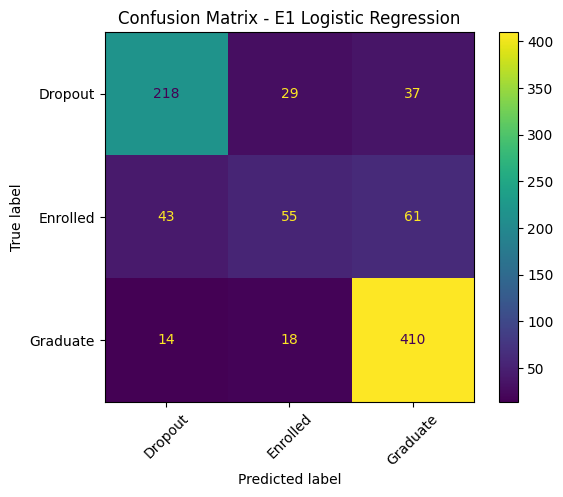

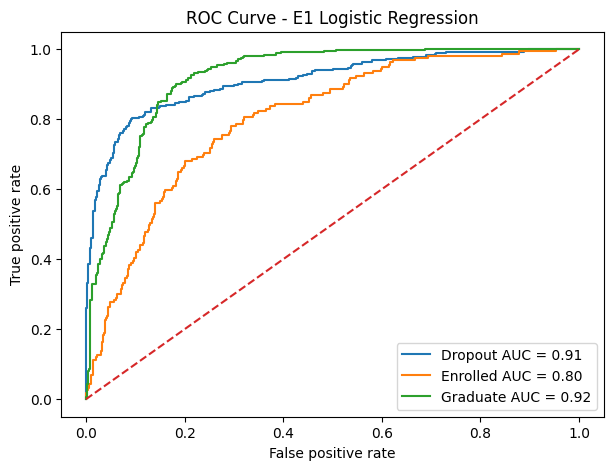

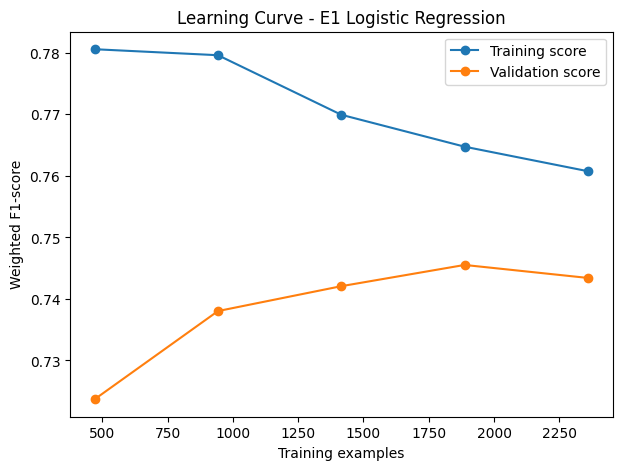

In [ ]:
#====================================
# Experiment 1: Logistic regression
#====================================

ml1 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=SEED))
])

ml1.fit(X_train_full, y_train_full)

pred = ml1.predict(X_test)
proba = ml1.predict_proba(X_test)

evaluate_model("E1 Logistic Regression", "Machine Learning", y_test, pred, proba)
plot_multiclass_roc(y_test, proba, "ROC Curve - E1 Logistic Regression")
plot_sklearn_learning_curve(ml1, X_train_full, y_train_full, "Learning Curve - E1 Logistic Regression")

## Experiment 2: Decision Tree


Decision Tree is easy to understand because it makes decisions using feature splits. I limit the depth to reduce overfitting.

===== E2 Decision Tree =====
Accuracy: 0.7582
Precision: 0.7525
Recall: 0.7582
F1-score: 0.7493

Classification report:
              precision    recall  f1-score   support

     Dropout       0.83      0.68      0.75       284
    Enrolled       0.53      0.43      0.48       159
    Graduate       0.79      0.93      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885



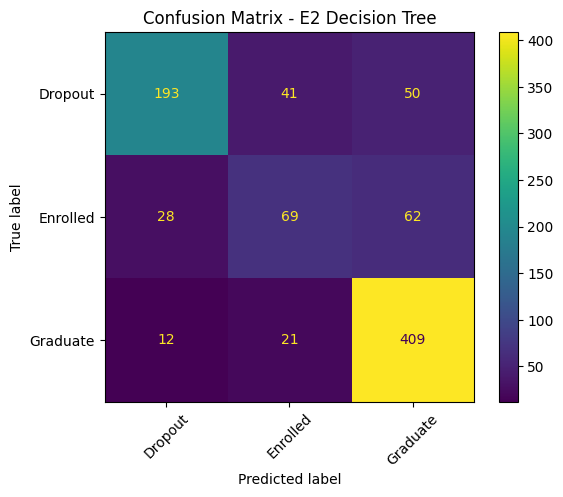

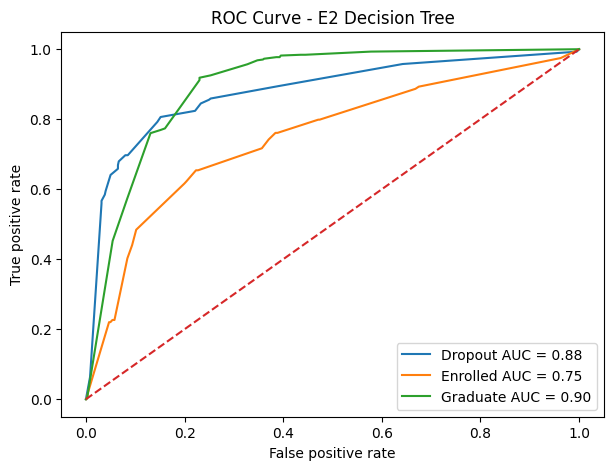

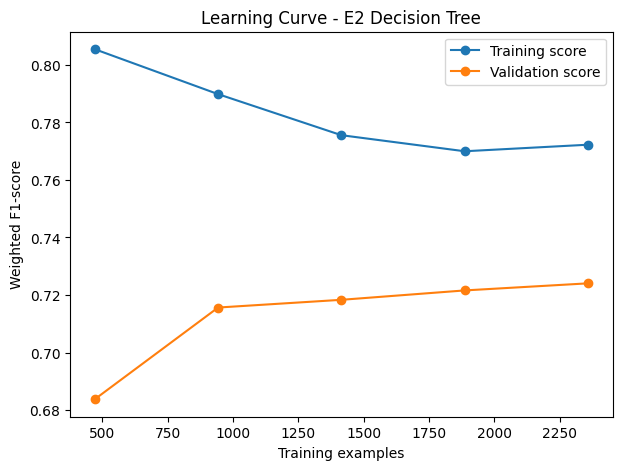

In [ ]:
#=================================
# Experiment 2: Decision tree
#=================================

ml2 = DecisionTreeClassifier(max_depth=5, random_state=SEED)

ml2.fit(X_train_full, y_train_full)

pred = ml2.predict(X_test)
proba = ml2.predict_proba(X_test)

evaluate_model("E2 Decision Tree", "Machine Learning", y_test, pred, proba)
plot_multiclass_roc(y_test, proba, "ROC Curve - E2 Decision Tree")
plot_sklearn_learning_curve(ml2, X_train_full, y_train_full, "Learning Curve - E2 Decision Tree")

## Experiment 3: Random Forest


Random Forest combines many decision trees. I used class weighting because the target classes are not perfectly balanced.

===== E3 Random Forest =====
Accuracy: 0.7356
Precision: 0.7682
Recall: 0.7356
F1-score: 0.7458

Classification report:
              precision    recall  f1-score   support

     Dropout       0.85      0.68      0.76       284
    Enrolled       0.43      0.62      0.51       159
    Graduate       0.84      0.81      0.83       442

    accuracy                           0.74       885
   macro avg       0.71      0.70      0.70       885
weighted avg       0.77      0.74      0.75       885



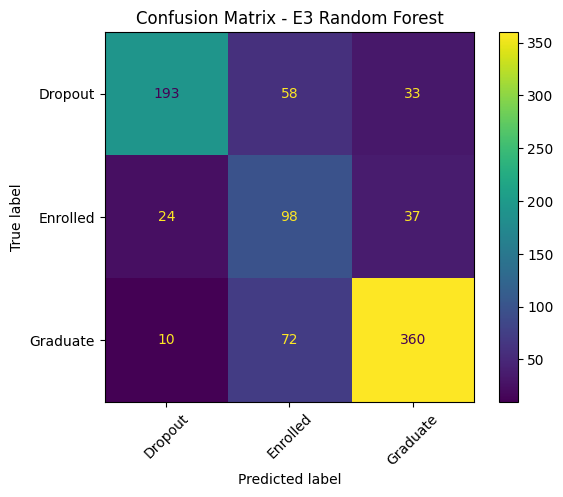

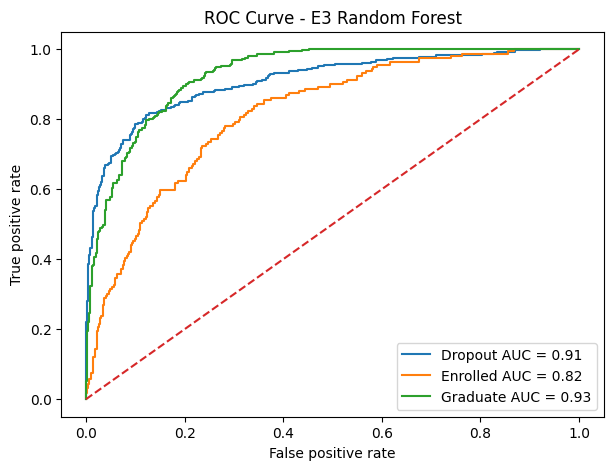

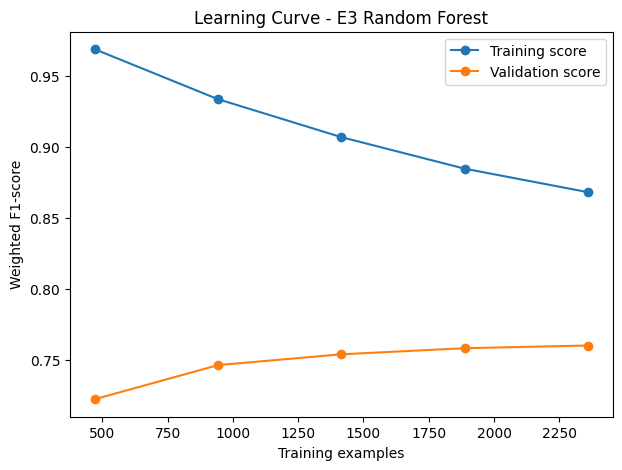

In [ ]:
#===================================
# Experiment 3: Random forest
#===================================

ml3 = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    random_state=SEED,
    class_weight="balanced"
)

ml3.fit(X_train_full, y_train_full)

pred = ml3.predict(X_test)
proba = ml3.predict_proba(X_test)

evaluate_model("E3 Random Forest", "Machine Learning", y_test, pred, proba)
plot_multiclass_roc(y_test, proba, "ROC Curve - E3 Random Forest")
plot_sklearn_learning_curve(ml3, X_train_full, y_train_full, "Learning Curve - E3 Random Forest")

## Experiment 4: Gradient Boosting


Gradient Boosting builds trees one after another. Each new tree tries to correct previous mistakes.

===== E4 Gradient Boosting =====
Accuracy: 0.7661
Precision: 0.7532
Recall: 0.7661
F1-score: 0.7555

Classification report:
              precision    recall  f1-score   support

     Dropout       0.79      0.75      0.77       284
    Enrolled       0.55      0.40      0.46       159
    Graduate       0.80      0.91      0.85       442

    accuracy                           0.77       885
   macro avg       0.71      0.68      0.69       885
weighted avg       0.75      0.77      0.76       885



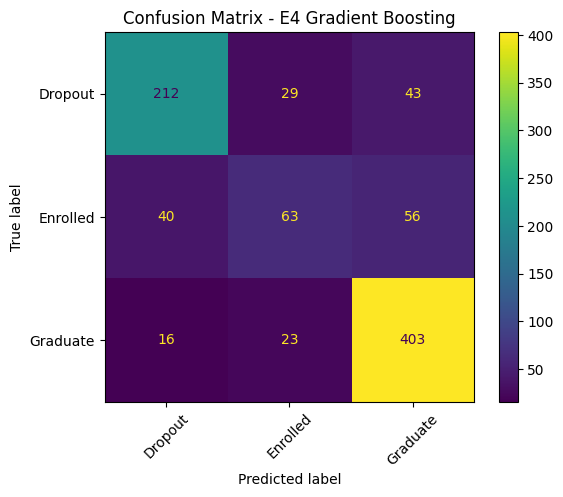

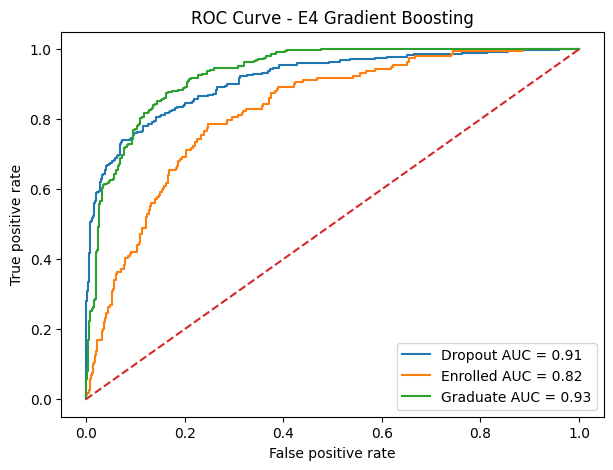

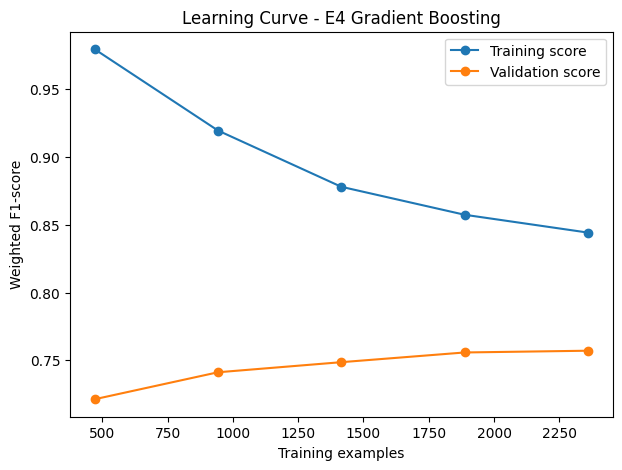

In [ ]:
#===================================
# Experiment 4: Gradient boosting
#===================================

ml4 = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.08,
    max_depth=3,
    random_state=SEED
)

ml4.fit(X_train_full, y_train_full)

pred = ml4.predict(X_test)
proba = ml4.predict_proba(X_test)

evaluate_model("E4 Gradient Boosting", "Machine Learning", y_test, pred, proba)
plot_multiclass_roc(y_test, proba, "ROC Curve - E4 Gradient Boosting")
plot_sklearn_learning_curve(ml4, X_train_full, y_train_full, "Learning Curve - E4 Gradient Boosting")

## Experiment 5: Support Vector Machine


SVM can create a non-linear boundary using the RBF kernel. I included probability=True so I can plot ROC curves.

===== E5 SVM RBF =====
Accuracy: 0.7661
Precision: 0.7559
Recall: 0.7661
F1-score: 0.7544

Classification report:
              precision    recall  f1-score   support

     Dropout       0.84      0.73      0.78       284
    Enrolled       0.52      0.38      0.44       159
    Graduate       0.78      0.93      0.85       442

    accuracy                           0.77       885
   macro avg       0.72      0.68      0.69       885
weighted avg       0.76      0.77      0.75       885



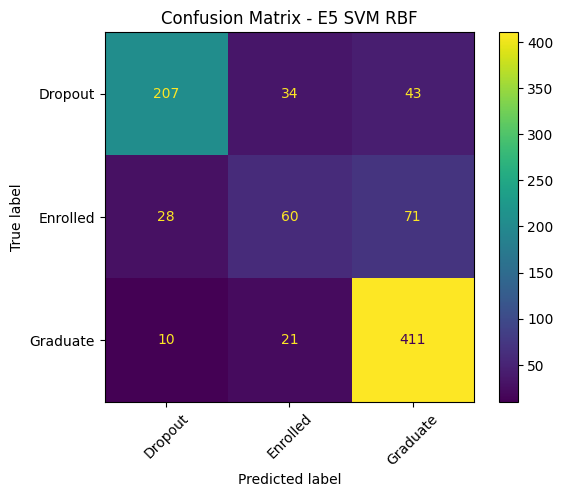

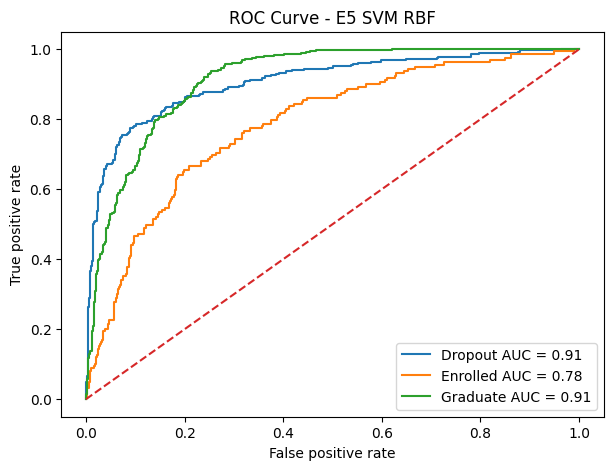

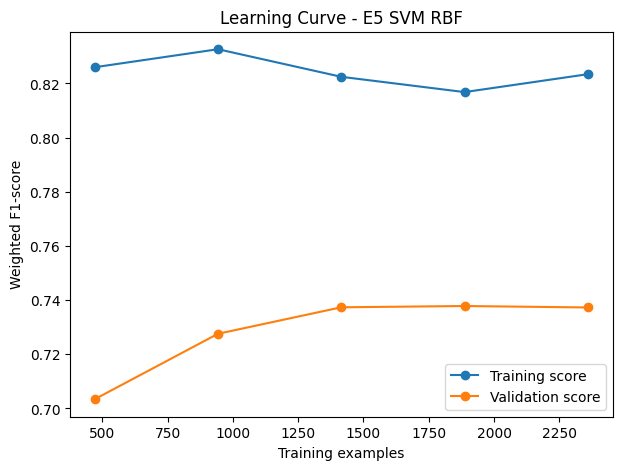

In [ ]:
#=====================================
# Experiment 5: Support vector machine
#=====================================

ml5 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1.0, probability=True, random_state=SEED))
])

ml5.fit(X_train_full, y_train_full)

pred = ml5.predict(X_test)
proba = ml5.predict_proba(X_test)

evaluate_model("E5 SVM RBF", "Machine Learning", y_test, pred, proba)
plot_multiclass_roc(y_test, proba, "ROC Curve - E5 SVM RBF")
plot_sklearn_learning_curve(ml5, X_train_full, y_train_full, "Learning Curve - E5 SVM RBF")

## Experiment 6: K-Nearest Neighbors


KNN predicts using the nearest examples in the training data. This model is simple, but it can be sensitive to scaling.

===== E6 KNN =====
Accuracy: 0.6847
Precision: 0.6666
Recall: 0.6847
F1-score: 0.6713

Classification report:
              precision    recall  f1-score   support

     Dropout       0.76      0.68      0.72       284
    Enrolled       0.33      0.24      0.28       159
    Graduate       0.73      0.85      0.78       442

    accuracy                           0.68       885
   macro avg       0.61      0.59      0.59       885
weighted avg       0.67      0.68      0.67       885



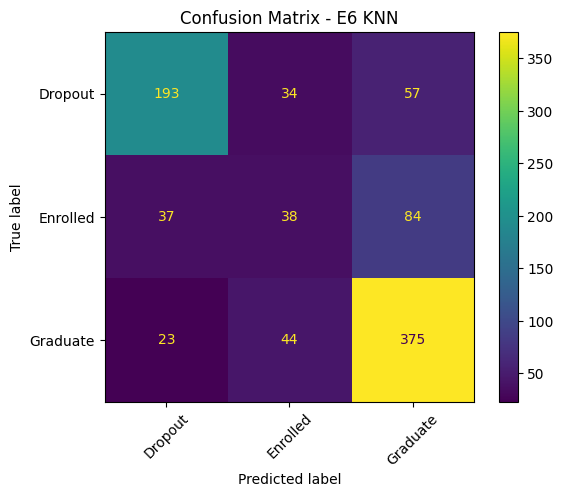

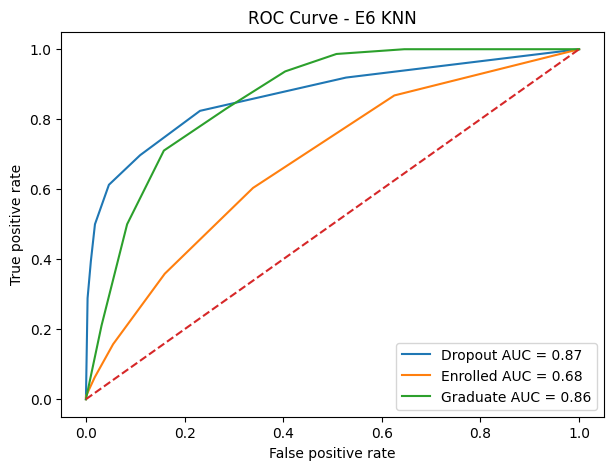

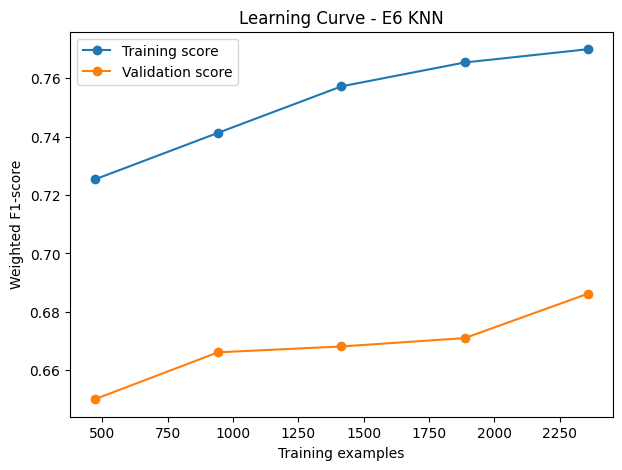

In [ ]:
#======================================
# Experiment 6: K-nearest neighbors
#======================================


ml6 = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

ml6.fit(X_train_full, y_train_full)

pred = ml6.predict(X_test)
proba = ml6.predict_proba(X_test)

evaluate_model("E6 KNN", "Machine Learning", y_test, pred, proba)
plot_multiclass_roc(y_test, proba, "ROC Curve - E6 KNN")
plot_sklearn_learning_curve(ml6, X_train_full, y_train_full, "Learning Curve - E6 KNN")

# Deep Learning Preparation

For the deep learning part, I used the TensorFlow `tf.data` API. This satisfies the assignment requirement and also makes batching and prefetching easier.

In [ ]:
BATCH_SIZE = 32

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train_scaled.astype("float32"), y_train.values.astype("int32"))
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val_scaled.astype("float32"), y_val.values.astype("int32"))
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test_scaled.astype("float32"), y_test.values.astype("int32"))
)

train_ds = train_ds.shuffle(
    buffer_size=len(X_train_scaled),
    seed=SEED
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("tf.data datasets are ready.")
print("Input dimension:", input_dim)

tf.data datasets are ready.
Input dimension: 40


## Deep learning helper functions

These functions compile the neural network, plot the learning curves, and evaluate the model on the test set.

In [ ]:
def compile_model(model, learning_rate=0.001):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


def plot_dl_history(history, title):
    plt.figure(figsize=(7, 5))
    plt.plot(history.history["accuracy"], label="Training accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation accuracy")
    plt.title(title + " - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 5))
    plt.plot(history.history["loss"], label="Training loss")
    plt.plot(history.history["val_loss"], label="Validation loss")
    plt.title(title + " - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


def evaluate_dl_model(name, model):
    y_proba = model.predict(X_test_scaled.astype("float32"))
    y_pred = np.argmax(y_proba, axis=1)

    evaluate_model(name, "Deep Learning", y_test, y_pred, y_proba)
    plot_multiclass_roc(y_test, y_proba, "ROC Curve - " + name)

## Experiment 7: Sequential API - Small Neural Network


This is my first deep learning baseline. It uses the Keras Sequential API with one hidden layer.

Architecture summary for E7:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,411 (5.51 KB)

 Trainable params: 1,411 (5.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5062 - loss: 1.0489 - val_accuracy: 0.6780 - val_loss: 0.7832
Epoch 2/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7068 - loss: 0.7251 - val_accuracy: 0.7316 - val_loss: 0.6701
Epoch 3/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7404 - loss: 0.6481 - val_accuracy: 0.7444 - val_loss: 0.6300
Epoch 4/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7556 - loss: 0.6115 - val_accuracy: 0.7542 - val_loss: 0.6099
Epoch 5/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7658 - loss: 0.5887 - val_accuracy: 0.7613 - val_loss: 0.5980
Epoch 6/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7697 - loss: 0.5743 - val_accuracy: 0.7655 - val_loss: 0.5918
Epoch 7/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7753 - loss: 0.5617 - val_accuracy: 0.7712 - val_loss: 0.5853
Epoch 8/20
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7775 - loss: 0.5511 - val_accuracy: 0.7641 - val_loss:

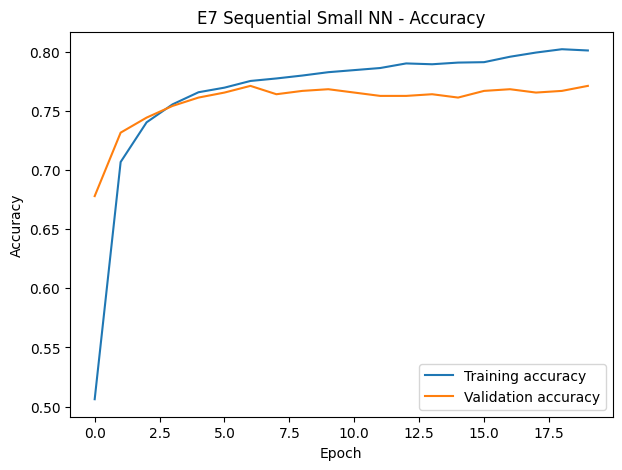

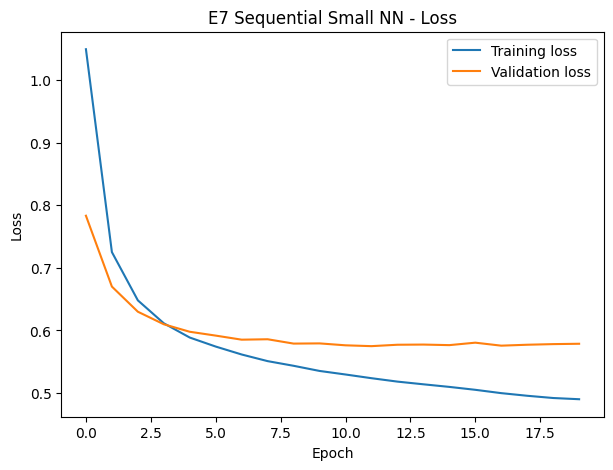

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
===== E7 Sequential Small NN =====
Accuracy: 0.7446
Precision: 0.7316
Recall: 0.7446
F1-score: 0.7353

Classification report:
              precision    recall  f1-score   support

     Dropout       0.78      0.73      0.75       284
    Enrolled       0.48      0.37      0.42       159
    Graduate       0.79      0.89      0.84       442

    accuracy                           0.74       885
   macro avg       0.68      0.66      0.67       885
weighted avg       0.73      0.74      0.74       885



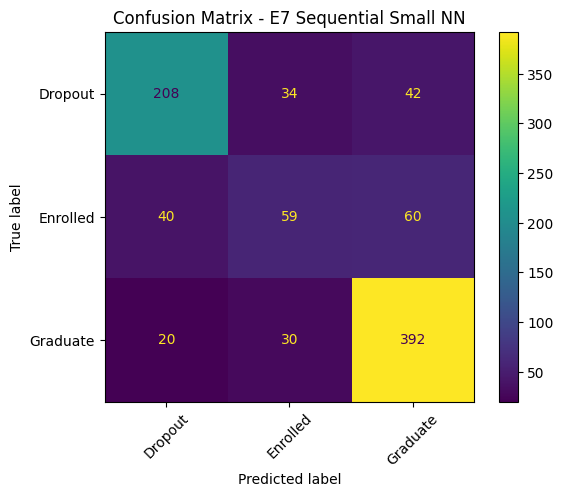

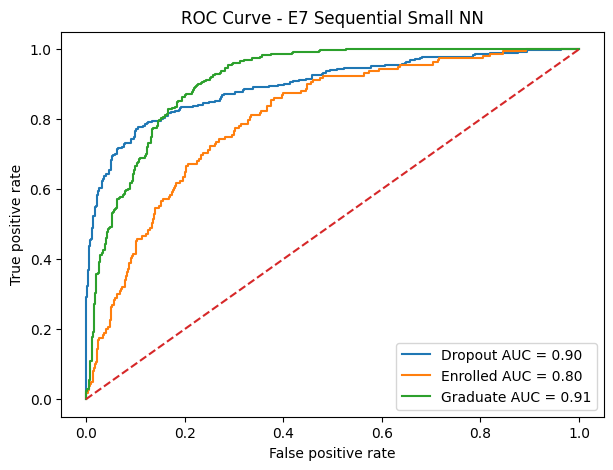

In [ ]:
#===================================
# Experiment 7: Sequential API- SNN
#===================================


def build_seq_small():
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    return compile_model(model, learning_rate=0.001)

dl1 = build_seq_small()

print("Architecture summary for E7:")
dl1.summary()

history1 = dl1.fit(train_ds, validation_data=val_ds, epochs=20, verbose=1)

plot_dl_history(history1, "E7 Sequential Small NN")
evaluate_dl_model("E7 Sequential Small NN", dl1)

## Experiment 8: Sequential API - Medium Neural Network with Dropout


This model is a bit deeper and uses dropout. Dropout helps reduce overfitting by randomly turning off some neurons during training.

Architecture summary for E8:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,803 (18.76 KB)

 Trainable params: 4,803 (18.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6369 - loss: 0.8714 - val_accuracy: 0.7472 - val_loss: 0.6660
Epoch 2/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7305 - loss: 0.6700 - val_accuracy: 0.7669 - val_loss: 0.6105
Epoch 3/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7513 - loss: 0.6263 - val_accuracy: 0.7613 - val_loss: 0.5996
Epoch 4/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7489 - loss: 0.6131 - val_accuracy: 0.7768 - val_loss: 0.5864
Epoch 5/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7644 - loss: 0.6045 - val_accuracy: 0.7712 - val_loss: 0.5870
Epoch 6/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7651 - loss: 0.5821 - val_accuracy: 0.7740 - val_loss: 0.5788
Epoch 7/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7655 - loss: 0.5804 - val_accuracy: 0.7740 - val_loss: 0.5734
Epoch 8/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7729 - loss: 0.5628 - val_accuracy: 0.7782 - val_loss

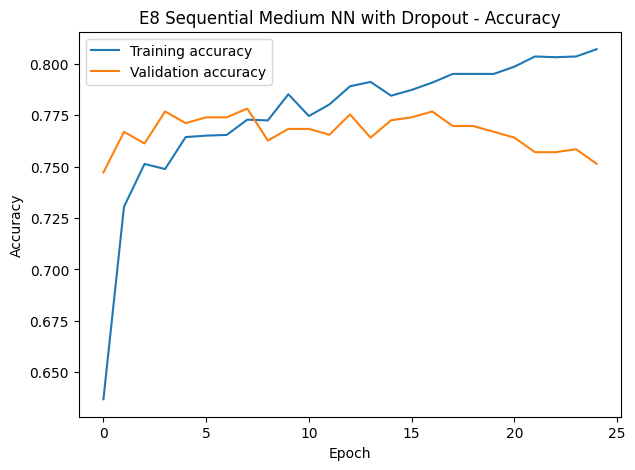

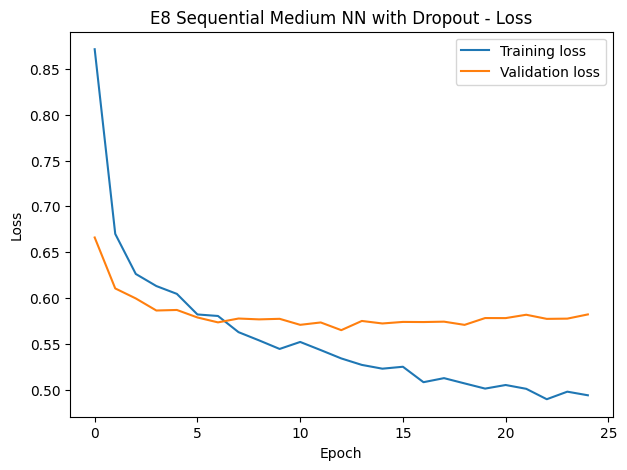

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
===== E8 Sequential Medium NN with Dropout =====
Accuracy: 0.748
Precision: 0.7409
Recall: 0.748
F1-score: 0.7436

Classification report:
              precision    recall  f1-score   support

     Dropout       0.78      0.74      0.76       284
    Enrolled       0.46      0.42      0.44       159
    Graduate       0.82      0.88      0.85       442

    accuracy                           0.75       885
   macro avg       0.69      0.68      0.68       885
weighted avg       0.74      0.75      0.74       885



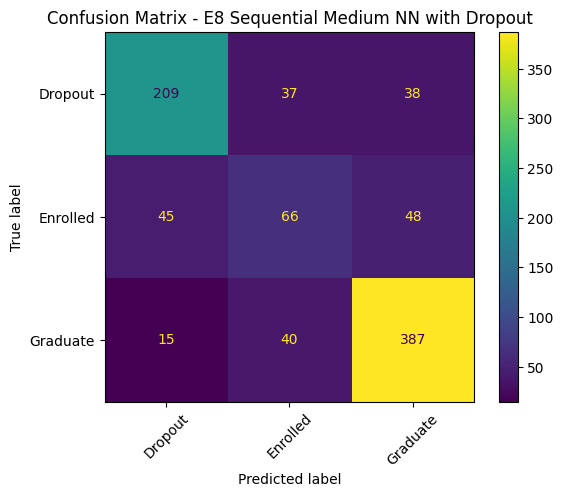

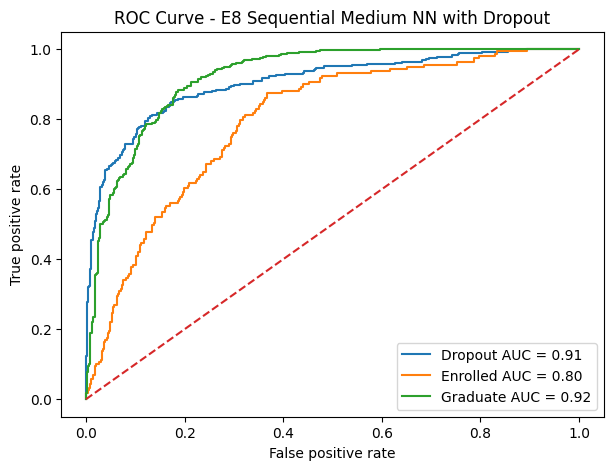

In [ ]:
#===================================================
# Experiment 8: Medium neural network with dropout
#===================================================


def build_seq_medium_dropout():
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.30),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    return compile_model(model, learning_rate=0.001)

dl2 = build_seq_medium_dropout()

print("Architecture summary for E8:")
dl2.summary()

history2 = dl2.fit(train_ds, validation_data=val_ds, epochs=25, verbose=1)

plot_dl_history(history2, "E8 Sequential Medium NN with Dropout")
evaluate_dl_model("E8 Sequential Medium NN with Dropout", dl2)

## Experiment 9: Sequential API - Lower Learning Rate


This experiment keeps a similar architecture but lowers the learning rate.

Architecture summary for E9:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,803 (18.76 KB)

 Trainable params: 4,803 (18.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5705 - loss: 1.0024 - val_accuracy: 0.6879 - val_loss: 0.8089
Epoch 2/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7051 - loss: 0.7337 - val_accuracy: 0.7331 - val_loss: 0.6761
Epoch 3/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7393 - loss: 0.6556 - val_accuracy: 0.7415 - val_loss: 0.6296
Epoch 4/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7570 - loss: 0.6287 - val_accuracy: 0.7542 - val_loss: 0.6160
Epoch 5/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7626 - loss: 0.6020 - val_accuracy: 0.7556 - val_loss: 0.5958
Epoch 6/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7602 - loss: 0.5918 - val_accuracy: 0.7655 - val_loss: 0.5913
Epoch 7/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7658 - loss: 0.5794 - val_accuracy: 0.7627 - val_loss: 0.5855
Epoch 8/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7736 - loss: 0.5687 - val_accuracy: 0.7613 - val_loss:

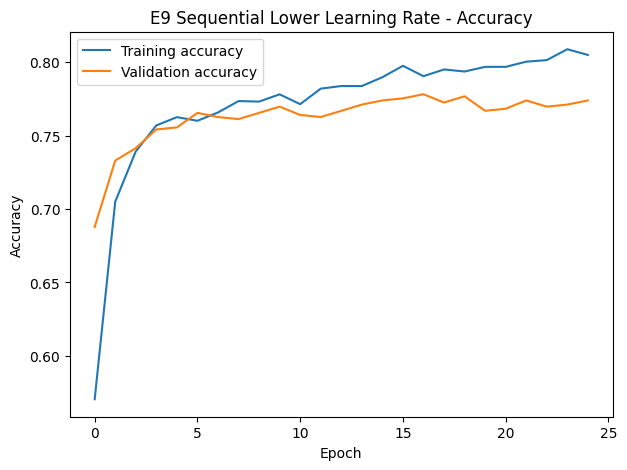

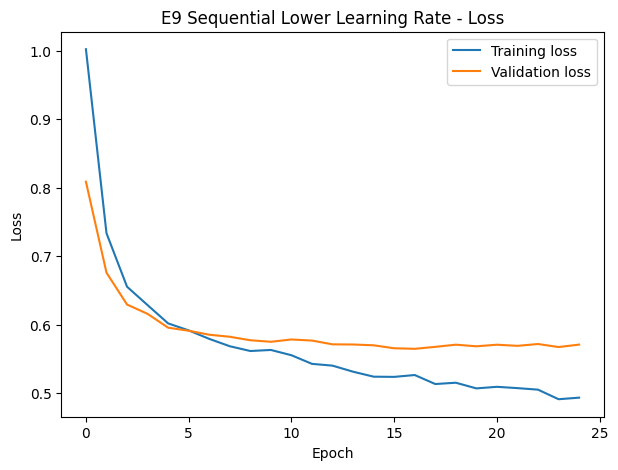

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
===== E9 Sequential Lower Learning Rate =====
Accuracy: 0.7537
Precision: 0.7447
Recall: 0.7537
F1-score: 0.7481

Classification report:
              precision    recall  f1-score   support

     Dropout       0.78      0.75      0.77       284
    Enrolled       0.49      0.42      0.45       159
    Graduate       0.81      0.88      0.84       442

    accuracy                           0.75       885
   macro avg       0.69      0.68      0.69       885
weighted avg       0.74      0.75      0.75       885



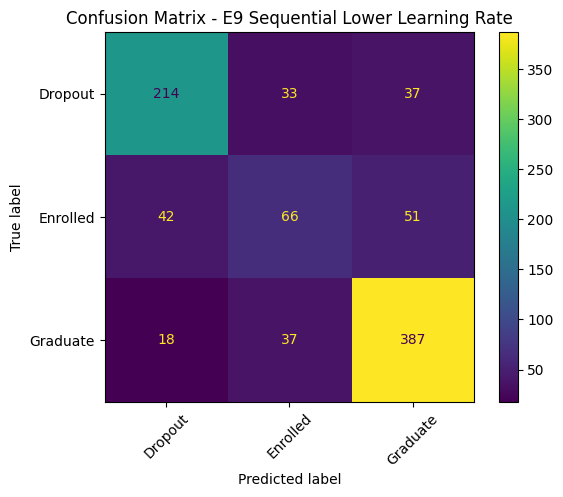

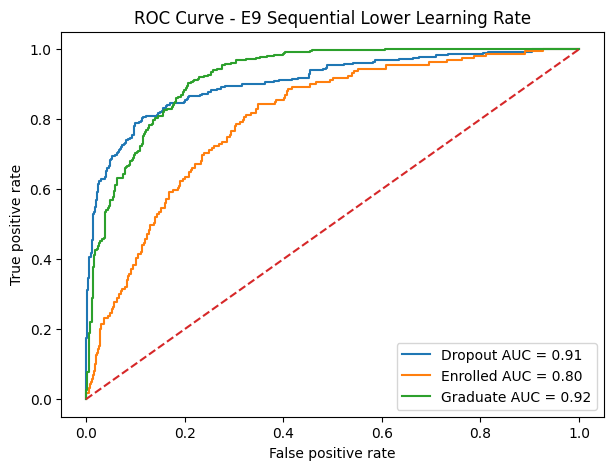

In [ ]:
#=========================================
# Experiment 9: Lower learning rate
#=========================================

def build_seq_low_lr():
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.20),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    return compile_model(model, learning_rate=0.0005)

dl3 = build_seq_low_lr()

print("Architecture summary for E9:")
dl3.summary()

history3 = dl3.fit(train_ds, validation_data=val_ds, epochs=25, verbose=1)

plot_dl_history(history3, "E9 Sequential Lower Learning Rate")
evaluate_dl_model("E9 Sequential Lower Learning Rate", dl3)

## Experiment 10: Functional API - Two Hidden Layers


This experiment uses the Keras Functional API. The architecture is still simple, but Functional API gives more flexibility for complex models.

Architecture summary for E10:


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,803 (18.76 KB)

 Trainable params: 4,803 (18.76 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6623 - loss: 0.8007 - val_accuracy: 0.7486 - val_loss: 0.6401
Epoch 2/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7538 - loss: 0.6109 - val_accuracy: 0.7655 - val_loss: 0.6012
Epoch 3/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7693 - loss: 0.5675 - val_accuracy: 0.7698 - val_loss: 0.5926
Epoch 4/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7785 - loss: 0.5437 - val_accuracy: 0.7669 - val_loss: 0.5915
Epoch 5/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7895 - loss: 0.5247 - val_accuracy: 0.7627 - val_loss: 0.5839
Epoch 6/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7916 - loss: 0.5091 - val_accuracy: 0.7684 - val_loss: 0.5824
Epoch 7/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8001 - loss: 0.4962 - val_accuracy: 0.7627 - val_loss: 0.5900
Epoch 8/25
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8068 - loss: 0.4845 - val_accuracy: 0.7627 - val_loss

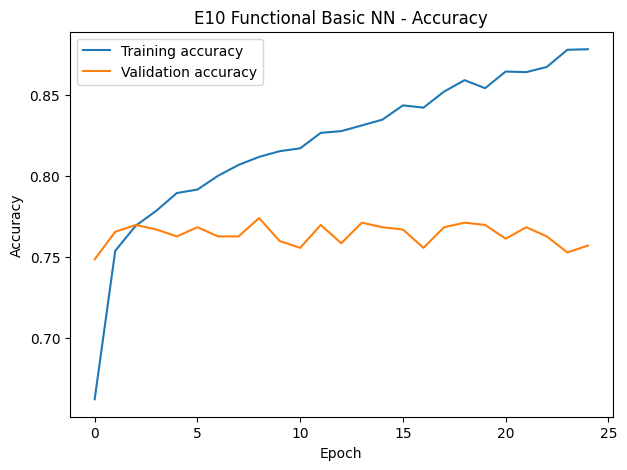

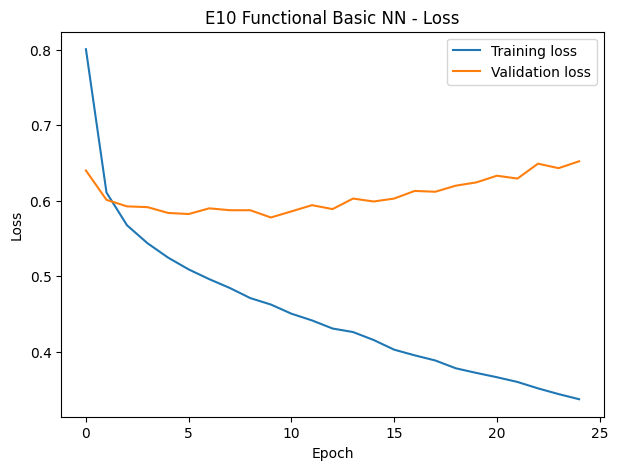

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
===== E10 Functional Basic NN =====
Accuracy: 0.7401
Precision: 0.7346
Recall: 0.7401
F1-score: 0.7367

Classification report:
              precision    recall  f1-score   support

     Dropout       0.77      0.73      0.75       284
    Enrolled       0.46      0.42      0.44       159
    Graduate       0.81      0.86      0.84       442

    accuracy                           0.74       885
   macro avg       0.68      0.67      0.67       885
weighted avg       0.73      0.74      0.74       885



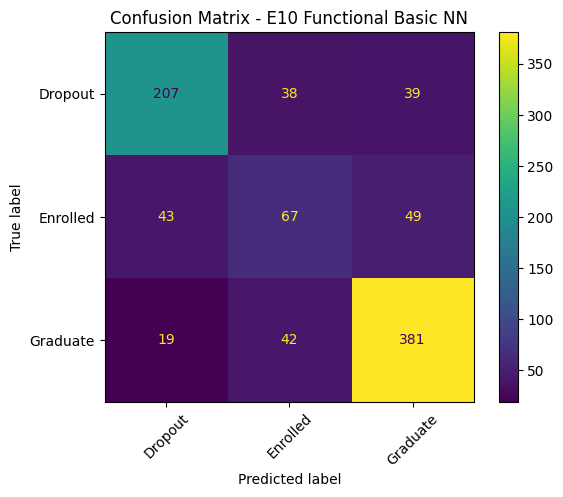

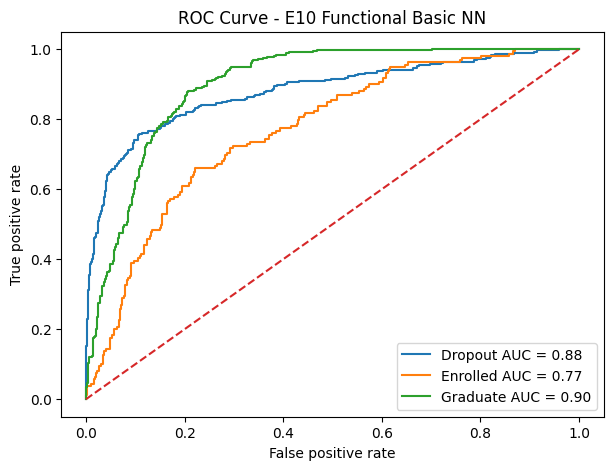

In [ ]:
#===================================
# Experiment 10: Twp hidden layers
#===================================

def build_functional_basic():
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(64, activation="relu")(inputs)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return compile_model(model, learning_rate=0.001)

dl4 = build_functional_basic()

print("Architecture summary for E10:")
dl4.summary()

history4 = dl4.fit(train_ds, validation_data=val_ds, epochs=25, verbose=1)

plot_dl_history(history4, "E10 Functional Basic NN")
evaluate_dl_model("E10 Functional Basic NN", dl4)

## Experiment 11: Functional API - Normalization


This model adds Normalization. Normalization can help make training more stable.

Architecture summary for E11:


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,211 (55.51 KB)

 Trainable params: 13,955 (54.51 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6605 - loss: 0.8466 - val_accuracy: 0.7359 - val_loss: 0.6989
Epoch 2/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7266 - loss: 0.6658 - val_accuracy: 0.7684 - val_loss: 0.6226
Epoch 3/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7460 - loss: 0.6257 - val_accuracy: 0.7698 - val_loss: 0.5965
Epoch 4/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7630 - loss: 0.5945 - val_accuracy: 0.7613 - val_loss: 0.5856
Epoch 5/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7623 - loss: 0.5885 - val_accuracy: 0.7669 - val_loss: 0.5880
Epoch 6/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7746 - loss: 0.5667 - val_accuracy: 0.7585 - val_loss: 0.5774
Epoch 7/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7831 - loss: 0.5342 - val_accuracy: 0.7698 - val_loss: 0.5758
Epoch 8/30
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7849 - loss: 0.5324 - val_accuracy: 0.7486 - val_loss:

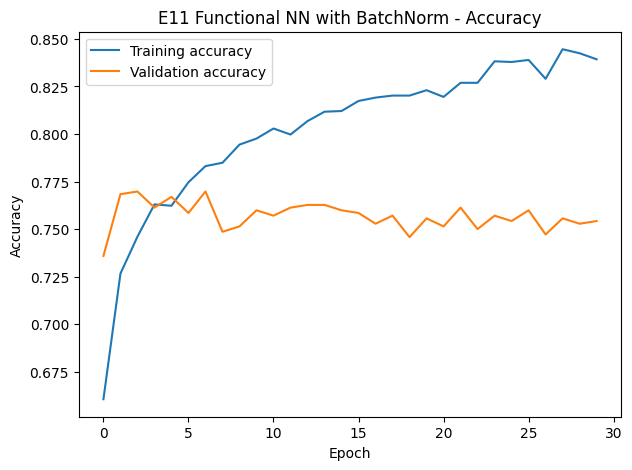

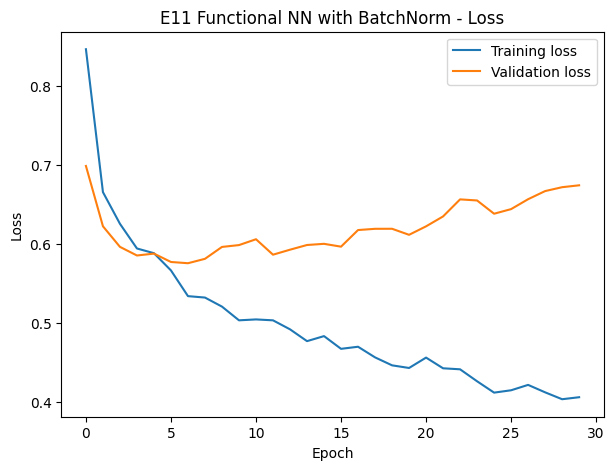

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
===== E11 Functional NN with BatchNorm =====
Accuracy: 0.7446
Precision: 0.7276
Recall: 0.7446
F1-score: 0.7337

Classification report:
              precision    recall  f1-score   support

     Dropout       0.78      0.76      0.77       284
    Enrolled       0.43      0.32      0.37       159
    Graduate       0.80      0.88      0.84       442

    accuracy                           0.74       885
   macro avg       0.67      0.66      0.66       885
weighted avg       0.73      0.74      0.73       885



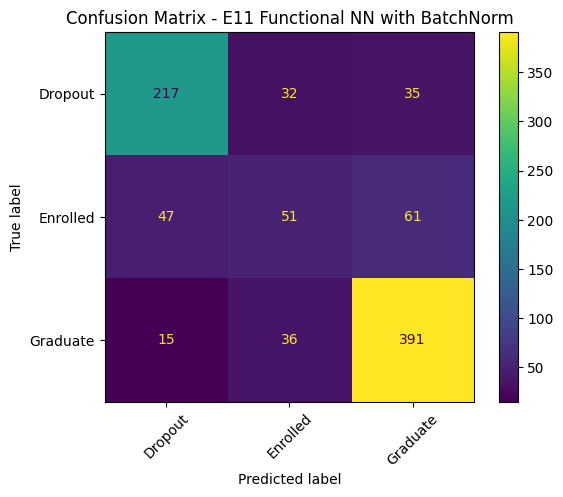

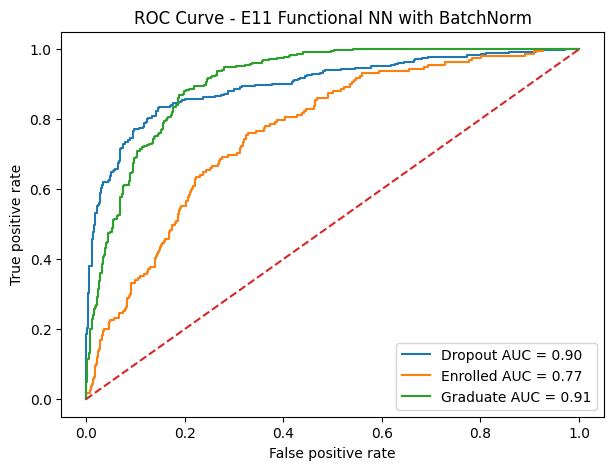

In [ ]:
#=====================================
# Experiment 11: Normalization
#=====================================

def build_functional_batchnorm():
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(128, activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return compile_model(model, learning_rate=0.001)

dl5 = build_functional_batchnorm()

print("Architecture summary for E11:")
dl5.summary()

history5 = dl5.fit(train_ds, validation_data=val_ds, epochs=30, verbose=1)

plot_dl_history(history5, "E11 Functional NN with BatchNorm")
evaluate_dl_model("E11 Functional NN with BatchNorm", dl5)

## Experiment 12: Functional API - Early Stopping


This final deep learning experiment i used early stopping. Early stopping stops training when validation loss no longer improves.

Architecture summary for E12:


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,699 (53.51 KB)

 Trainable params: 13,699 (53.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6669 - loss: 0.8044 - val_accuracy: 0.7486 - val_loss: 0.6316
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7308 - loss: 0.6567 - val_accuracy: 0.7472 - val_loss: 0.6212
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7496 - loss: 0.6199 - val_accuracy: 0.7641 - val_loss: 0.5903
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7489 - loss: 0.6094 - val_accuracy: 0.7698 - val_loss: 0.5880
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7686 - loss: 0.5855 - val_accuracy: 0.7613 - val_loss: 0.5795
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7757 - loss: 0.5688 - val_accuracy: 0.7599 - val_loss: 0.5898
Epoch 7/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7789 - loss: 0.5479 - val_accuracy: 0.7684 - val_loss: 0.5840
Epoch 8/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7838 - loss: 0.5468 - val_accuracy: 0.7613 - val_loss:

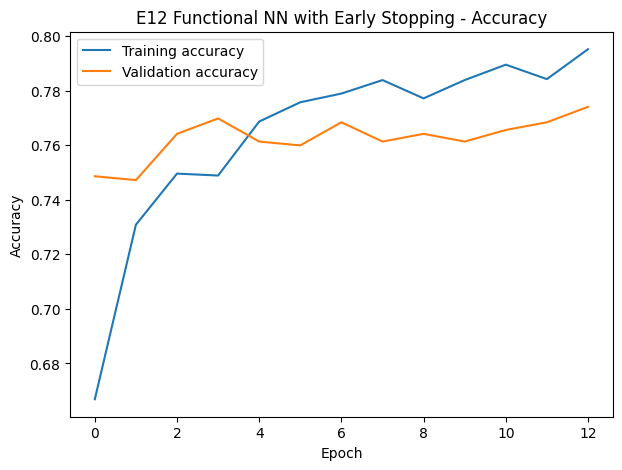

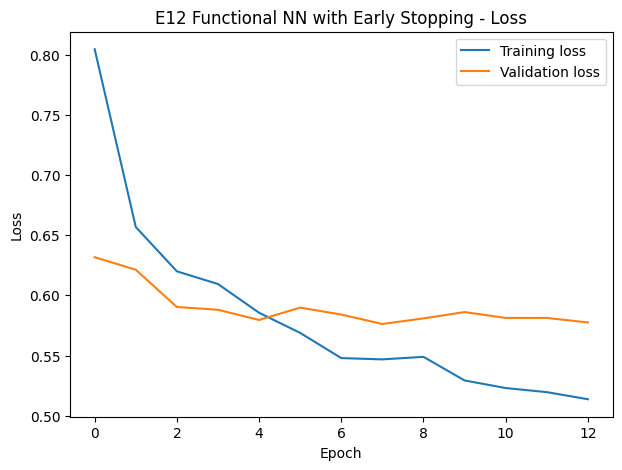

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
===== E12 Functional NN with Early Stopping =====
Accuracy: 0.7706
Precision: 0.7538
Recall: 0.7706
F1-score: 0.7561

Classification report:
              precision    recall  f1-score   support

     Dropout       0.83      0.77      0.80       284
    Enrolled       0.51      0.33      0.40       159
    Graduate       0.79      0.93      0.85       442

    accuracy                           0.77       885
   macro avg       0.71      0.68      0.69       885
weighted avg       0.75      0.77      0.76       885



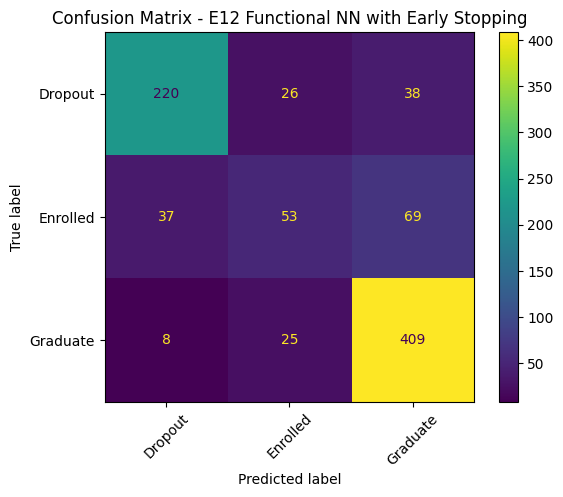

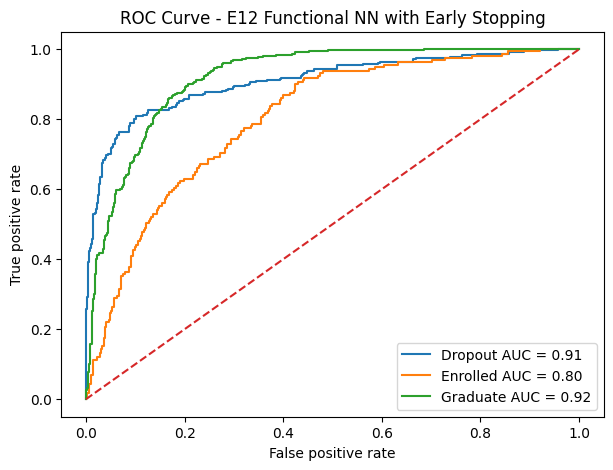

In [ ]:
#===================================
#Experiment 12: Early stopping
#===================================

def build_functional_earlystop():
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(128, activation="relu")(inputs)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.20)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return compile_model(model, learning_rate=0.001)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

dl6 = build_functional_earlystop()

print("Architecture summary for E12:")
dl6.summary()

history6 = dl6.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop],
    verbose=1
)

plot_dl_history(history6, "E12 Functional NN with Early Stopping")
evaluate_dl_model("E12 Functional NN with Early Stopping", dl6)

# Final Results Comparison

This table shows the comparision between all 12 experiments. I arraged the models by weighted F1-score because the project is multiclass and the classes are not exactly equal in size.

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="F1-score", ascending=False).reset_index(drop=True)

results_df

,Experiment,Type,Accuracy,Precision,Recall,F1-score
0,E1 Logistic Regression,Machine Learning,0.771751,0.754353,0.771751,0.757104
1,E1 Logistic Regression,Machine Learning,0.771751,0.754353,0.771751,0.757104
2,E12 Functional NN with Early Stopping,Deep Learning,0.770621,0.753839,0.770621,0.756050
3,E4 Gradient Boosting,Machine Learning,0.766102,0.753213,0.766102,0.755534
4,E4 Gradient Boosting,Machine Learning,0.766102,0.753213,0.766102,0.755534
5,E5 SVM RBF,Machine Learning,0.766102,0.755854,0.766102,0.754371
6,E2 Decision Tree,Machine Learning,0.758192,0.752515,0.758192,0.749320
7,E2 Decision Tree,Machine Learning,0.758192,0.752515,0.758192,0.749320
8,E9 Sequential Lower Learning Rate,Deep Learning,0.753672,0.744730,0.753672,0.748084
9,E8 Sequential Medium NN with Dropout,Deep Learning,0.755932,0.743539,0.755932,0.747254


## Final comparison plot

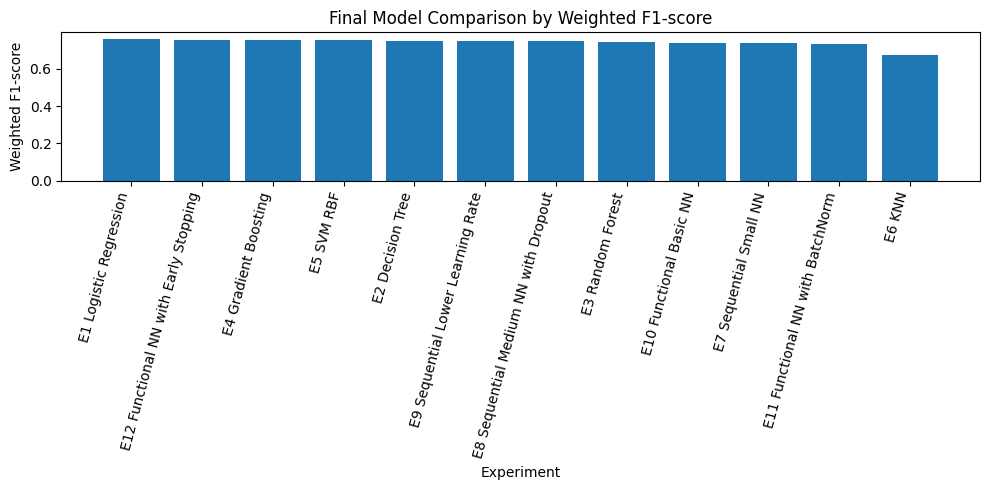

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["Experiment"], results_df["F1-score"])
plt.title("Final Model Comparison by Weighted F1-score")
plt.xlabel("Experiment")
plt.ylabel("Weighted F1-score")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()